In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("./Household energy unit data.csv")
df

,num_rooms,num_people,housearea,is_ac,is_tv,is_flat,num_children,is_urban,units
0,3,3,742.57,1,1,1,2,0,134.731117
1,1,5,952.99,0,1,0,1,1,125.315527
2,3,1,761.44,1,1,1,0,0,123.047874
3,0,5,861.32,1,1,0,0,0,80.046162
4,1,8,731.61,0,1,0,2,1,128.429094
...,...,...,...,...,...,...,...,...,...
995,3,0,991.31,0,1,0,1,1,128.128283
996,2,5,847.97,0,1,0,0,0,85.209782
997,2,4,660.94,1,0,0,0,1,117.267814
998,1,1,814.75,0,1,1,0,1,127.823576


In [5]:
df.isnull().sum()

num_rooms       0
num_people      0
housearea       0
is_ac           0
is_tv           0
is_flat         0
num_children    0
is_urban        0
units           0
dtype: int64

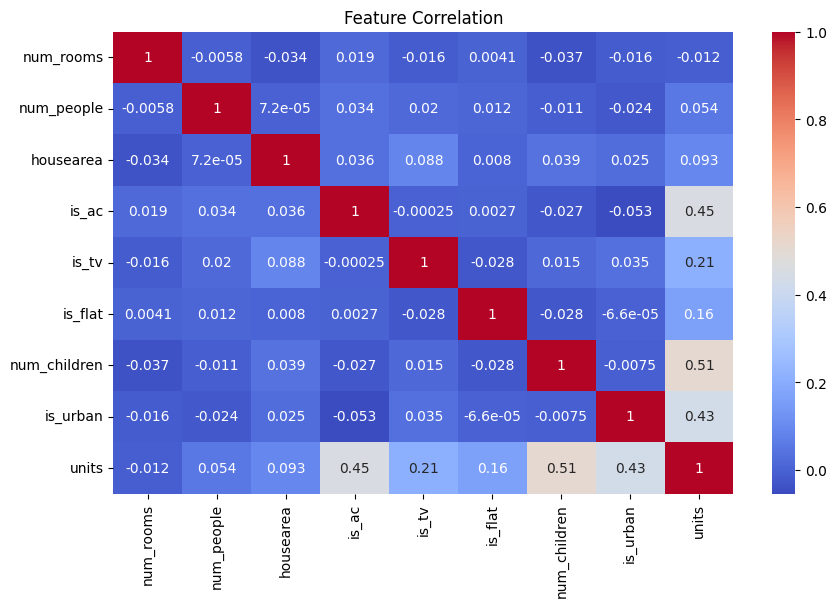

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

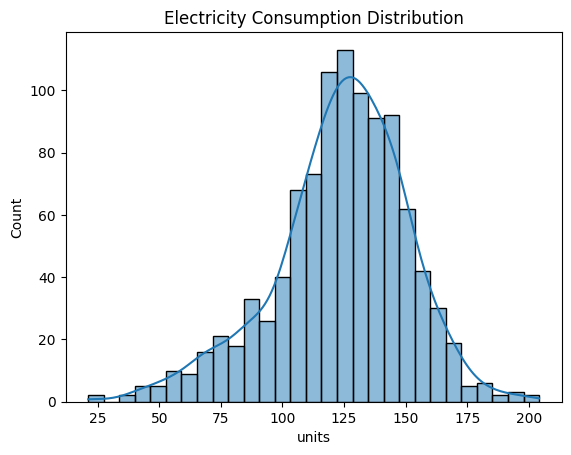

In [8]:
sns.histplot(df["units"], kde=True)
plt.title("Electricity Consumption Distribution")
plt.show()

In [10]:
# Select features and target

X = df.drop("units", axis=1)
y = df["units"]



In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

# Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

# Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error

print("KNN MAE:", mean_absolute_error(y_test, knn_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Decision Tree MAE:", mean_absolute_error(y_test, pred_dt))
print("Linear Regression MAE:", mean_absolute_error(y_test, pred_lr))

KNN MAE: 11.13694680998
Random Forest MAE: 10.723997747539498
Decision Tree MAE: 13.378946185900002
Linear Regression MAE: 11.171926901476436


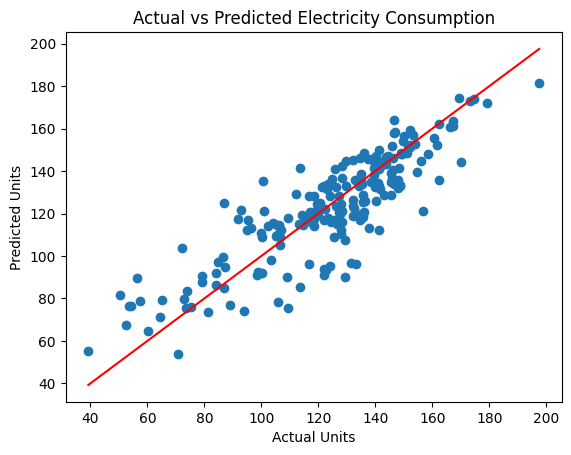

In [24]:
plt.scatter(y_test, rf_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Units")
plt.ylabel("Predicted Units")
plt.title("Actual vs Predicted Electricity Consumption")
plt.show()

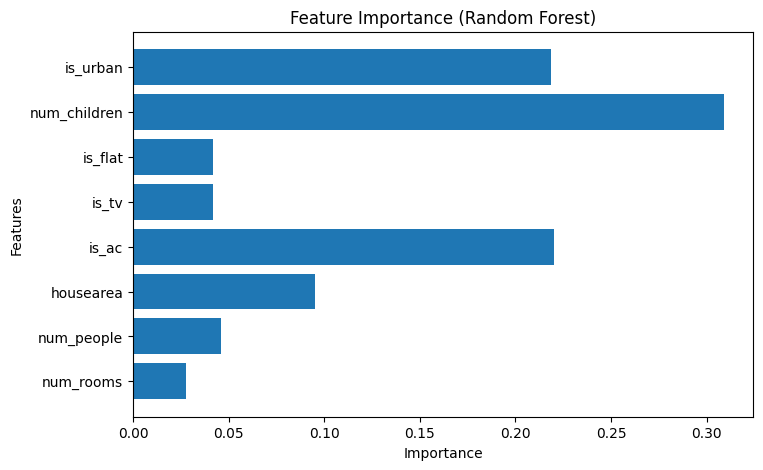

In [25]:
importance = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [26]:
# Take inputs from user
num_rooms = int(input("Enter number of rooms: "))
num_people = int(input("Enter number of people: "))
housearea = float(input("Enter house area: "))
is_ac = int(input("AC present? (1 = Yes, 0 = No): "))
is_tv = int(input("TV present? (1 = Yes, 0 = No): "))
is_flat = int(input("Is it a flat? (1 = Yes, 0 = No): "))
num_children = int(input("Enter number of children: "))
is_urban = int(input("Urban area? (1 = Yes, 0 = No): "))

# Create dataframe
new_house = pd.DataFrame({
    "num_rooms":[num_rooms],
    "num_people":[num_people],
    "housearea":[housearea],
    "is_ac":[is_ac],
    "is_tv":[is_tv],
    "is_flat":[is_flat],
    "num_children":[num_children],
    "is_urban":[is_urban]
})

new_house_scaled = scaler.transform(new_house)
# Predict using Random Forest
prediction = rf.predict(new_house_scaled)
print("Predicted Electricity Consumption:", round(prediction[0], 2), "Units")

Enter number of rooms:  3
Enter number of people:  4
Enter house area:  1000
AC present? (1 = Yes, 0 = No):  1
TV present? (1 = Yes, 0 = No):  1
Is it a flat? (1 = Yes, 0 = No):  1
Enter number of children:  2
Urban area? (1 = Yes, 0 = No):  1


Predicted Electricity Consumption: 165.22 Units
